# Problema 1 — Word Cloud

**Proyecto Final · Text Mining & Image Recognition**
Postgrado en Análisis y Predicción de Datos — Tercer Trimestre, 2026

> **Este es el notebook 1 de 2.** El Problema 2 (*Fruits and Vegetables Recognizer*) está
> en `Problema2_CNN_Frutas.ipynb`, pensado para ejecutarse localmente en VS Code.

---

##  Ejecutar en Google Colab

Este notebook está preparado para **Google Colab**, como pide el enunciado. No hace falta
configurar nada: la celda de instalación detecta el entorno y la de datos descarga el dataset
automáticamente.

---

## Enunciado

**Objetivo.** Sobre un dataset de tweets, usar **expresiones regulares** para determinar los
**3 usuarios más populares**, construir un **corpus por usuario** (`Content` = tweet;
`Metadata` = ID, Timestamp, Length) y responder **¿por qué citan a ese usuario?** analizando
el **contexto** (las palabras que rodean la mención) tras remover *stopwords*, aplicar
*stemming* y *lemmatización*, y mostrando un **wordcloud con el top 10** por usuario.

**Criterio de popularidad.** Un usuario es popular cuando *los demás hablan de él*, no cuando
él tuitea mucho. Por eso la popularidad se mide como el **número de tweets que lo mencionan**
(`@usuario`), extraídos con regex. Se cuentan *tweets distintos* y no menciones totales, para
que un mismo tweet que repita `@miley ... @miley` no infle el conteo.

## 1.0 Configuración del entorno

In [1]:
# Instalacion de dependencias: solo se ejecuta si estamos en Colab.
# En local basta con  pip install -r requirements.txt
try:
    import google.colab          # noqa: F401
    EN_COLAB = True
    !pip install -q wordcloud nltk kagglehub
except ImportError:
    EN_COLAB = False

print("Entorno:", "Google Colab" if EN_COLAB else "local (VS Code / Jupyter)")

Entorno: local (VS Code / Jupyter)


In [2]:
import os, re, sys, html, textwrap
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from wordcloud import WordCloud

for _recurso in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    nltk.download(_recurso, quiet=True)

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 110)
print("Entorno listo | Python", sys.version.split()[0], "| pandas", pd.__version__)

Entorno listo | Python 3.12.0 | pandas 3.0.5


## 1.1 Obtención del dataset

El dataset son ~1.6 M de tweets (*Sentiment140*, 239 MB), demasiado grande para versionarlo en
GitHub. La celda siguiente lo resuelve sola:

- **Si `datos/tw_source.csv` ya existe** (ejecución local), lo usa y no descarga nada.
- **Si no existe** (Colab recién abierto), lo baja de Kaggle con `kagglehub`.

> 

In [3]:
# Rutas del proyecto
RAIZ        = Path.cwd()
DIR_DATOS   = RAIZ / "datos"
DIR_SALIDAS = RAIZ / "salidas" / "problema1"
DIR_DATOS.mkdir(parents=True, exist_ok=True)
DIR_SALIDAS.mkdir(parents=True, exist_ok=True)

CSV_TWEETS = DIR_DATOS / "tw_source.csv"

if not CSV_TWEETS.exists():
    print("No se encontro el CSV local. Descargando Sentiment140 desde Kaggle ...")
    import shutil
    import kagglehub

    ruta = Path(kagglehub.dataset_download("kazanova/sentiment140"))
    origen = next(ruta.rglob("*.csv"))          # training.1600000.processed.noemoticon.csv
    shutil.copy(origen, CSV_TWEETS)
    print("Descargado y copiado a", CSV_TWEETS)

print("CSV:", CSV_TWEETS.name, f"({CSV_TWEETS.stat().st_size / 1e6:.1f} MB)")

CSV: tw_source.csv (238.8 MB)


### Carga del dataset

El archivo viene **sin encabezado** y con el esquema clásico de *Sentiment140*:

| # | Columna | Significado |
|---|---|---|
| 0 | `target` | polaridad (0 = negativo, 4 = positivo) |
| 1 | `id` | identificador del tweet |
| 2 | `date` | fecha y hora del tweet |
| 3 | `flag` | query usada (`NO_QUERY` en todo el archivo) |
| 4 | `user` | **autor** del tweet |
| 5 | `text` | texto del tweet |

Se lee con `encoding="latin-1"` porque el archivo no es UTF-8 válido.

In [4]:
COLUMNAS = ["target", "id", "date", "flag", "user", "text"]

tweets = pd.read_csv(CSV_TWEETS, encoding="latin-1", header=None, names=COLUMNAS)
tweets["text"] = tweets["text"].astype(str)

# "Mon Apr 06 22:19:45 PDT 2009" -> datetime (la zona PDT es constante en el archivo)
tweets["timestamp"] = pd.to_datetime(
    tweets["date"].str.replace(" PDT ", " ", regex=False),
    format="%a %b %d %H:%M:%S %Y",
    errors="coerce",
)

print(f"Tweets             : {len(tweets):,}")
print(f"Autores distintos  : {tweets['user'].nunique():,}")
print(f"Rango temporal     : {tweets['timestamp'].min()}  ->  {tweets['timestamp'].max()}")
print(f"Fechas no parseadas: {tweets['timestamp'].isna().sum()}")
tweets.head(3)

Tweets             : 1,600,000


Autores distintos  : 659,775
Rango temporal     : 2009-04-06 22:19:45  ->  2009-06-25 10:28:31
Fechas no parseadas: 0


,target,id,date,flag,user,text,timestamp
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to ...",2009-04-06 22:19:45
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. ...,2009-04-06 22:19:49
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,2009-04-06 22:19:53


## 1.2 Los 3 usuarios más populares (expresiones regulares)

La regex `@(\w{1,15})` replica la regla de Twitter: el identificador va precedido de `@` y
admite entre 1 y 15 caracteres alfanuméricos o guion bajo. Se normaliza a minúsculas porque
el *handle* de Twitter no distingue mayúsculas (`@MileyCyrus` == `@mileycyrus`).

In [5]:
RE_MENCION = re.compile(r"@(\w{1,15})")
RE_URL     = re.compile(r"https?://\S+|www\.\S+")

def menciones(texto):
    """Handles citados en un tweet, en minusculas y sin repeticiones."""
    return {m.lower() for m in RE_MENCION.findall(texto)}

# Popularidad = en cuantos tweets distintos aparece citado el usuario
conteo_menciones = Counter()
for _t in tweets["text"]:
    conteo_menciones.update(menciones(_t))

print(f"Handles citados al menos una vez: {len(conteo_menciones):,}")

ranking = (pd.DataFrame(conteo_menciones.most_common(20),
                        columns=["usuario", "tweets_que_lo_citan"])
             .assign(pct_del_dataset=lambda d: (100 * d["tweets_que_lo_citan"] / len(tweets)).round(3)))
ranking

Handles citados al menos una vez: 343,632


,usuario,tweets_que_lo_citan,pct_del_dataset
0,mileycyrus,4562,0.285
1,tommcfly,3898,0.244
2,ddlovato,3460,0.216
3,jonasbrothers,2382,0.149
4,davidarchie,1381,0.086
5,donniewahlberg,1328,0.083
6,jonathanrknight,1264,0.079
7,jordanknight,1146,0.072
8,mitchelmusso,1102,0.069
9,taylorswift13,1025,0.064


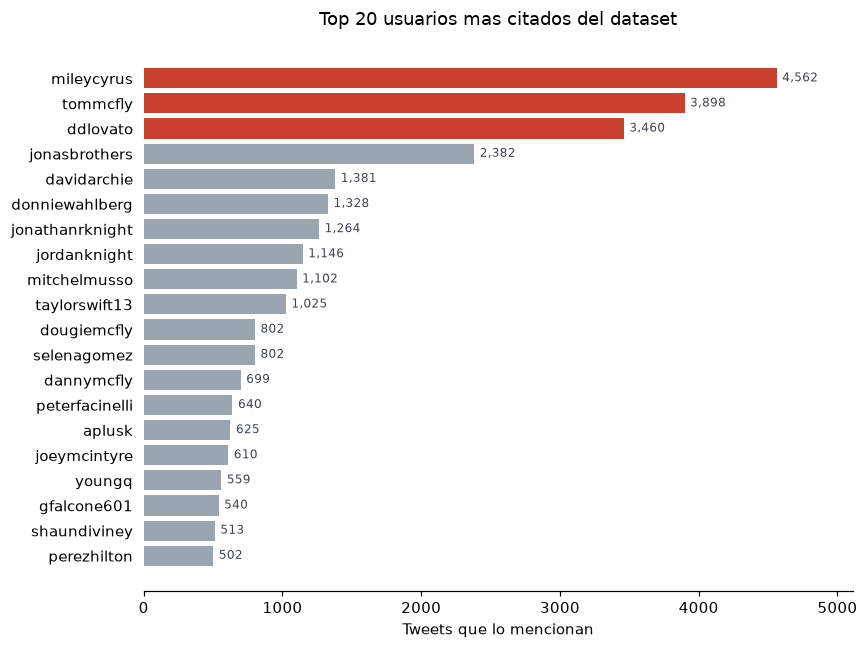

In [6]:
top20 = ranking.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#c9412e" if i >= 17 else "#9aa5b1" for i in range(len(top20))]
ax.barh(top20["usuario"], top20["tweets_que_lo_citan"], color=colores)
for y, v in zip(top20["usuario"], top20["tweets_que_lo_citan"]):
    ax.text(v + 40, y, f"{v:,}", va="center", fontsize=8, color="#3b444f")
ax.set_title("Top 20 usuarios mas citados del dataset", fontsize=12, pad=12)
ax.set_xlabel("Tweets que lo mencionan")
ax.set_xlim(0, top20["tweets_que_lo_citan"].max() * 1.12)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "top20_usuarios_citados.png", bbox_inches="tight")
plt.show()

In [7]:
TOP_USUARIOS = [u for u, _ in conteo_menciones.most_common(3)]

print("Los 3 usuarios mas populares del dataset:\n")
for i, u in enumerate(TOP_USUARIOS, 1):
    print(f"  {i}. @{u:<14} citado en {conteo_menciones[u]:>6,} tweets")

Los 3 usuarios mas populares del dataset:

  1. @mileycyrus     citado en  4,562 tweets
  2. @tommcfly       citado en  3,898 tweets
  3. @ddlovato       citado en  3,460 tweets


## 1.3 Construcción de los corpus

Para cada uno de los 3 usuarios se arma un corpus con los tweets que lo citan. La estructura
sigue la convención `Content` / `Metadata` del enunciado:

- **Content** → el texto del tweet.
- **Metadata** → `ID` (id del tweet), `Timestamp` (fecha y hora) y `Length`, **valor que hay
  que calcular**: número de caracteres del tweet. Se agrega `LengthPalabras` como apoyo y
  `Autor` para poder rastrear quién escribió la mención.

In [8]:
@dataclass
class Documento:
    """Un tweet del corpus: contenido + metadatos."""
    content: str
    meta: dict = field(default_factory=dict)

    def __repr__(self):
        return f"<Documento ID={self.meta.get('ID')} Length={self.meta.get('Length')}>"


@dataclass
class Corpus:
    """Coleccion de documentos asociada a un usuario citado."""
    usuario: str
    documentos: list = field(default_factory=list)

    def __len__(self):
        return len(self.documentos)

    def __iter__(self):
        return iter(self.documentos)

    def to_frame(self):
        return pd.DataFrame([{"Content": d.content, **d.meta} for d in self.documentos])


def construir_corpus(usuario, df):
    """Corpus con los tweets que citan a `usuario` (handle exacto, no prefijos)."""
    patron = re.compile(rf"@{re.escape(usuario)}\b", re.IGNORECASE)
    seleccion = df[df["text"].str.contains(patron, na=False)]

    docs = [
        Documento(
            content=fila.text,
            meta={
                "ID": int(fila.id),
                "Timestamp": fila.timestamp,
                "Length": len(fila.text),               # <- metadato calculado
                "LengthPalabras": len(fila.text.split()),
                "Autor": fila.user,
            },
        )
        for fila in seleccion.itertuples(index=False)
    ]
    return Corpus(usuario=usuario, documentos=docs)


corpora = {u: construir_corpus(u, tweets) for u in TOP_USUARIOS}

for u, c in corpora.items():
    print(f"@{u:<14} -> {len(c):>6,} documentos   {c.documentos[0]!r}")

@mileycyrus     ->  4,562 documentos   <Documento ID=1468063101 Length=107>
@tommcfly       ->  3,898 documentos   <Documento ID=1468210813 Length=138>
@ddlovato       ->  3,460 documentos   <Documento ID=1467929230 Length=47>


In [9]:
# Resumen de los metadatos calculados
resumen = pd.DataFrame([
    {
        "Usuario": f"@{u}",
        "Documentos": len(c),
        "Length medio": round(c.to_frame()["Length"].mean(), 1),
        "Length mediano": int(c.to_frame()["Length"].median()),
        "Length max": int(c.to_frame()["Length"].max()),
        "Palabras medias": round(c.to_frame()["LengthPalabras"].mean(), 1),
        "Primer tweet": c.to_frame()["Timestamp"].min(),
        "Ultimo tweet": c.to_frame()["Timestamp"].max(),
    }
    for u, c in corpora.items()
])
resumen

,Usuario,Documentos,Length medio,Length mediano,Length max,Palabras medias,Primer tweet,Ultimo tweet
0,@mileycyrus,4562,85.2,84,156,14.7,2009-04-06 22:38:51,2009-06-25 10:24:28
1,@tommcfly,3898,86.6,87,201,15.5,2009-04-06 22:22:49,2009-06-25 10:19:55
2,@ddlovato,3460,87.6,87,154,15.7,2009-04-06 22:42:52,2009-06-25 08:37:32


In [10]:
# Vista del corpus y persistencia en disco
display(corpora[TOP_USUARIOS[0]].to_frame().head(5))

for u, c in corpora.items():
    destino = DIR_SALIDAS / f"corpus_{u}.csv"
    c.to_frame().to_csv(destino, index=False, encoding="utf-8")
    print("guardado:", destino.name, f"({len(c):,} filas)")

,Content,ID,Timestamp,Length,LengthPalabras,Autor
0,@mileycyrus hahaha dont be like that one time in NY when you got 30 mins of sleep then got sick love you!!,1468063101,2009-04-06 23:30:57,107,22,kristenn_lynn
1,"@mileycyrus i have the same problem, but it's 4:43 here... let's see if counting works..1234...56 57 58......",1468286517,2009-04-07 00:45:20,137,24,nathiuria
2,@mileycyrus I guess counting sheep didn't work Hope you get some sleep!,1468297110,2009-04-07 00:49:07,72,12,amyamoore
3,@mileycyrus I would too if it meant spending a day in heaven w/my mom and getting to see her again.,1468298918,2009-04-07 00:49:44,100,20,xdokkenx
4,@mileycyrus AWWW u seriously have the cutest dog Miley! Sorry your not with her now Hope u get some sleep...,1468318249,2009-04-07 00:56:41,112,21,XFearLessX


guardado: corpus_mileycyrus.csv (4,562 filas)
guardado: corpus_tommcfly.csv (3,898 filas)
guardado: corpus_ddlovato.csv (3,460 filas)


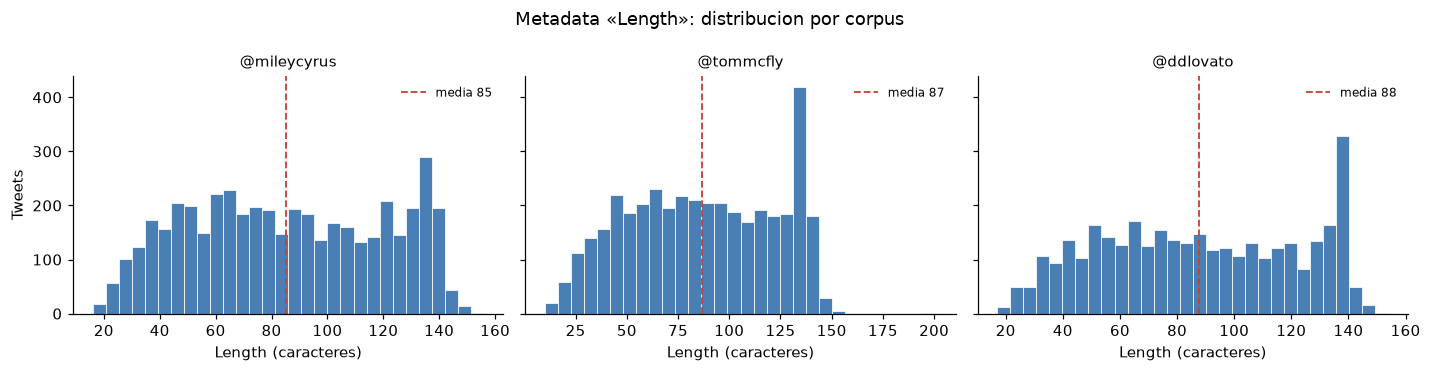

In [11]:
# Distribucion del metadato Length por corpus
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (u, c) in zip(axes, corpora.items()):
    serie = c.to_frame()["Length"]
    ax.hist(serie, bins=30, color="#4a7fb5", edgecolor="white", linewidth=0.5)
    ax.axvline(serie.mean(), color="#c9412e", linestyle="--", linewidth=1.2,
               label=f"media {serie.mean():.0f}")
    ax.set_title(f"@{u}", fontsize=10)
    ax.set_xlabel("Length (caracteres)")
    ax.legend(fontsize=8, frameon=False)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("Tweets")
plt.suptitle("Metadata «Length»: distribucion por corpus", fontsize=12)
plt.tight_layout()
plt.savefig(DIR_SALIDAS / "distribucion_length.png", bbox_inches="tight")
plt.show()

## 1.4 Extracción del contexto de la mención

No todas las palabras de un tweet explican *por qué* se cita al usuario. Un tweet como

> *«just woke up so tired ... @mileycyrus please reply ... going to the mall later»*

habla del centro comercial y de la mención en la misma cadena. Por eso se extrae una
**ventana de contexto**: las `V` palabras a la izquierda y las `V` a la derecha del handle.
Con `V = 5` se captura la frase que acompaña a la mención sin arrastrar el resto del tweet.

Decisiones de limpieza, motivadas por lo ruidoso de los datos:

1. `html.unescape` — el dataset trae entidades sin decodificar (`&quot;`, `&amp;`, `&lt;`).
2. Se eliminan **URLs**: no aportan significado al contexto.
3. La mención objetivo se sustituye por el marcador `__OBJETIVO__`, para localizarla después
   de tokenizar.
4. **Las demás menciones se eliminan**: en `@mileycyrus @ddlovato vote for them`, el handle
   `@ddlovato` no es una palabra de contexto sino otro destinatario del mismo mensaje.

In [12]:
VENTANA  = 5
MARCADOR = "__OBJETIVO__"
RE_TOKEN = re.compile(rf"{MARCADOR}|[A-Za-z']+")

def contexto(texto, usuario, ventana=VENTANA):
    """Palabras dentro de la ventana +/- `ventana` alrededor de cada mencion a `usuario`."""
    texto = html.unescape(texto)
    texto = RE_URL.sub(" ", texto)
    texto = re.sub(rf"@{re.escape(usuario)}\b", f" {MARCADOR} ", texto, flags=re.IGNORECASE)
    texto = RE_MENCION.sub(" ", texto)          # otros destinatarios fuera

    tokens = [t if t == MARCADOR else t.lower() for t in RE_TOKEN.findall(texto)]

    alrededor = []
    for i, t in enumerate(tokens):
        if t != MARCADOR:
            continue
        izq = tokens[max(0, i - ventana): i]
        der = tokens[i + 1: i + 1 + ventana]
        alrededor += [w for w in izq + der if w != MARCADOR]
    return alrededor


# Ejemplo: tweet completo vs. contexto extraido
_ejemplo = corpora[TOP_USUARIOS[0]].documentos[7].content
print("TWEET    :", textwrap.fill(html.unescape(_ejemplo), 96))
print("CONTEXTO :", contexto(_ejemplo, TOP_USUARIOS[0]))

TWEET    : @mileycyrus http://twitpic.com/2y606 - I want a Sofie!  She's helllza cute.
CONTEXTO : ['i', 'want', 'a', 'sofie', "she's"]


## 1.5 Normalización: stopwords, stemming y lemmatización

Tres pasos sobre los tokens del contexto:

1. **Remover stopwords.** A la lista de NLTK en inglés se le suma un diccionario propio de
   ruido de Twitter: contracciones que pierden el apóstrofo al tokenizar (`im`, `dont`,
   `cant`), abreviaturas SMS (`u`, `ur`, `pls`), interjecciones (`lol`, `omg`, `aww`) y
   verbos vacíos de altísima frecuencia (`get`, `go`, `like`). Sin esta limpieza el top 10
   se llena de muletillas y no dice nada del usuario.
2. **Stemming** (`SnowballStemmer`) — recorta a la raíz: *voting → vote*, *loving → love*.
   Es agresivo y produce formas que no son palabras reales (*beautiful → beauti*).
3. **Lemmatización** (`WordNetLemmatizer`) — devuelve el lema de diccionario (*loves → love*,
   *wishes → wish*), preservando legibilidad. Se lematiza primero como verbo y luego como
   sustantivo, porque WordNet necesita la categoría gramatical y en tweets predomina el verbo.

Ambos se calculan y se comparan, como pide el enunciado. Para el **wordcloud se usa el lema**,
porque una nube debe mostrar palabras legibles.

In [13]:
STOPWORDS_EN = set(stopwords.words("english"))

RUIDO_TWITTER = {
    # contracciones que pierden el apostrofo al tokenizar
    "im", "dont", "cant", "wont", "didnt", "isnt", "aint", "ive", "ill", "id",
    "youre", "youve", "thats", "hes", "shes", "theyre", "wasnt", "couldnt", "wouldnt",
    # abreviaturas y SMS-speak
    "u", "ur", "pls", "plz", "thx", "tho", "cuz", "gonna", "wanna", "gotta",
    "rt", "amp", "quot", "nbsp", "www", "com",
    # interjecciones
    "lol", "lmao", "omg", "haha", "hahaha", "hehe", "aww", "awww", "ohh",
    "yeah", "yea", "yep", "nope", "hmm", "wow", "yay",
    # verbos y adverbios vacios de altisima frecuencia
    "get", "got", "go", "going", "went", "like", "just", "really", "much", "many",
    "one", "way", "thing", "today", "day", "time", "back", "still", "even", "also",
    "make", "take", "let", "would", "could", "should", "know", "say", "said", "well",
}
STOPWORDS = STOPWORDS_EN | RUIDO_TWITTER

lematizador = WordNetLemmatizer()
stemmer     = SnowballStemmer("english")

def normalizar(tokens, modo="lema"):
    """Filtra stopwords/tokens cortos y aplica lematizacion o stemming."""
    salida = []
    for t in tokens:
        t = t.strip("'")
        if len(t) < 3 or not t.isalpha() or t in STOPWORDS:
            continue
        lema = lematizador.lemmatize(lematizador.lemmatize(t, pos="v"), pos="n")
        if lema in STOPWORDS:
            continue
        salida.append(stemmer.stem(lema) if modo == "stem" else lema)
    return salida


_demo = contexto(_ejemplo, TOP_USUARIOS[0])
print("crudo :", _demo)
print("lema  :", normalizar(_demo, "lema"))
print("stem  :", normalizar(_demo, "stem"))

crudo : ['i', 'want', 'a', 'sofie', "she's"]


lema  : ['want', 'sofie']
stem  : ['want', 'sofi']


In [14]:
def frecuencias_contexto(corpus, modo="lema"):
    """Frecuencia de las palabras de contexto en todo el corpus de un usuario."""
    frec = Counter()
    for doc in corpus:
        frec.update(normalizar(contexto(doc.content, corpus.usuario), modo=modo))
    return frec


contextos_lema = {u: frecuencias_contexto(c, "lema") for u, c in corpora.items()}
contextos_stem = {u: frecuencias_contexto(c, "stem") for u, c in corpora.items()}

columnas = {}
for u in TOP_USUARIOS:
    columnas[f"@{u} | lema"] = [f"{w} ({n})" for w, n in contextos_lema[u].most_common(10)]
    columnas[f"@{u} | stem"] = [f"{w} ({n})" for w, n in contextos_stem[u].most_common(10)]

comparacion = pd.DataFrame(columnas, index=range(1, 11))
comparacion.index.name = "#"
comparacion

,@mileycyrus | lema,@mileycyrus | stem,@tommcfly | lema,@tommcfly | stem,@ddlovato | lema,@ddlovato | stem
#,,,,,,
1,miley (599),miley (600),tom (572),tom (572),demi (424),demi (425)
2,love (361),love (371),hey (154),hey (154),love (257),love (262)
3,vote (277),vote (280),please (153),pleas (153),wish (170),wish (170)
4,good (176),good (176),good (141),love (150),come (121),come (121)
5,hey (175),hey (175),love (139),good (141),hey (120),hey (120)
6,come (170),come (171),come (134),come (134),please (109),pleas (109)
7,hope (148),hope (157),miss (103),miss (103),hope (103),hope (108)
8,please (116),pleas (116),think (100),think (100),wait (99),wait (99)
9,luck (105),luck (105),reply (98),repli (98),see (97),see (97)


## 1.6 Wordclouds con el top 10 por usuario

La nube se construye **solo con las 10 palabras más frecuentes** del contexto de cada usuario,
tal como pide el enunciado, y se acompaña de un gráfico de barras con las frecuencias exactas:
la nube comunica el tema de un vistazo, las barras permiten leer la magnitud.

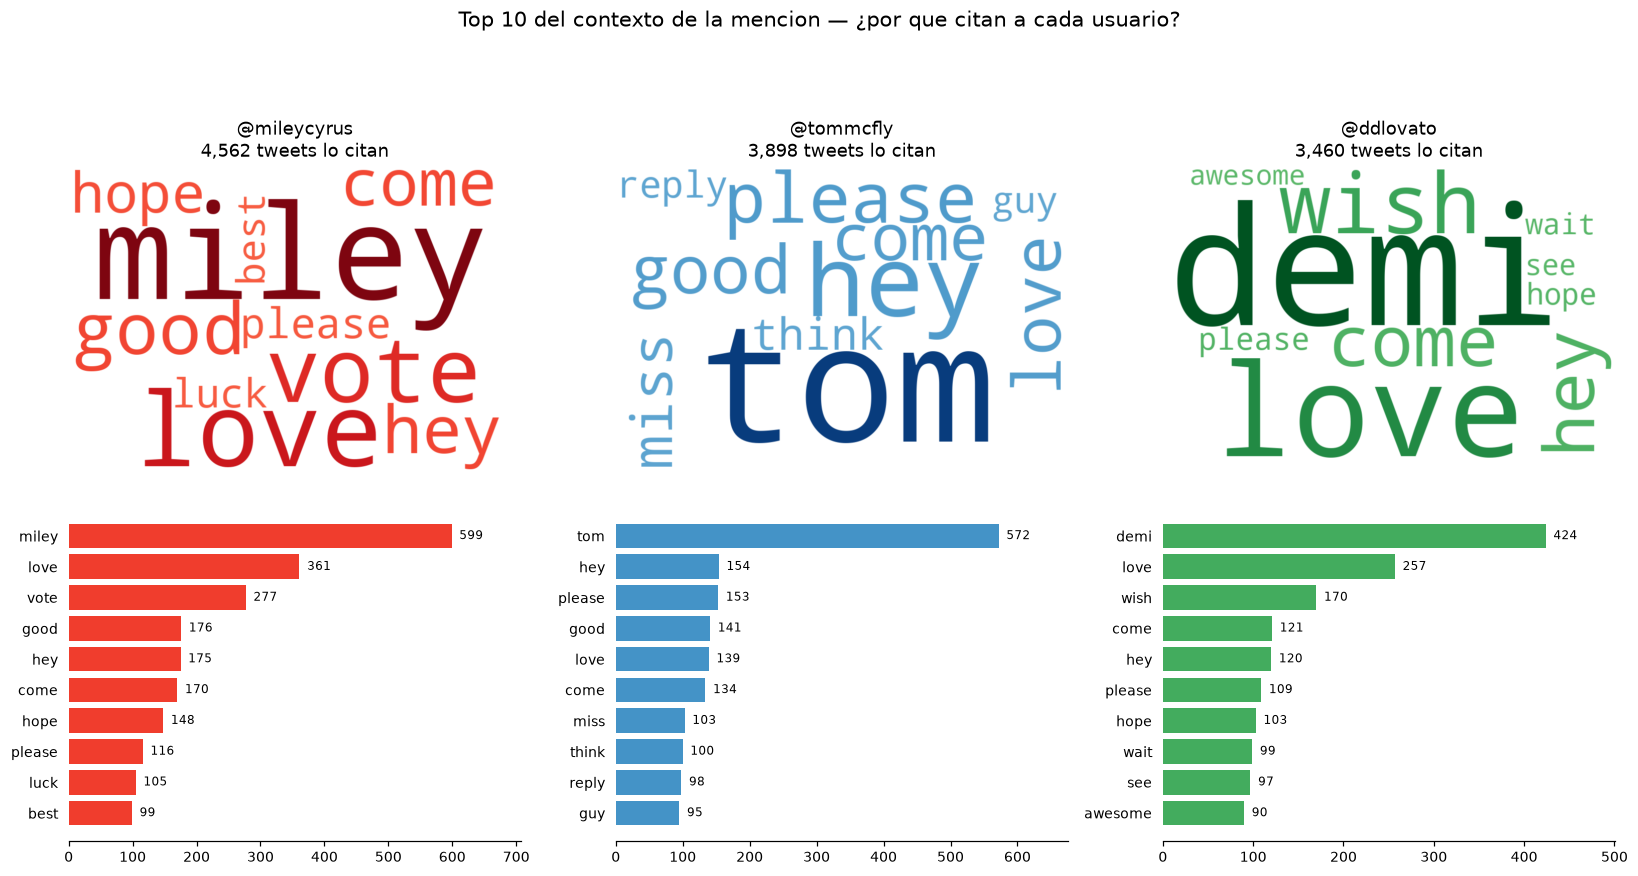

In [15]:
TOP_N   = 10
PALETAS = ["Reds", "Blues", "Greens"]   # claro -> oscuro: garantiza contraste sobre blanco

tops = {u: dict(contextos_lema[u].most_common(TOP_N)) for u in TOP_USUARIOS}

def color_por_frecuencia(paleta, frecuencias):
    """Colorea cada palabra segun su peso: mas frecuente -> mas oscura (nunca ilegible)."""
    cmap = plt.get_cmap(paleta)
    maximo = max(frecuencias.values())
    def color(word, **kwargs):
        intensidad = 0.45 + 0.50 * (frecuencias[word] / maximo)   # rango legible del mapa
        r, g, b, _ = cmap(intensidad)
        return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"
    return color


fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={"height_ratios": [1.35, 1]})

for j, u in enumerate(TOP_USUARIOS):
    nube = WordCloud(width=900, height=600, background_color="white",
                     color_func=color_por_frecuencia(PALETAS[j], tops[u]),
                     prefer_horizontal=0.95, relative_scaling=0.55,
                     max_words=TOP_N, random_state=42).generate_from_frequencies(tops[u])

    axes[0, j].imshow(nube, interpolation="bilinear")
    axes[0, j].axis("off")
    axes[0, j].set_title(f"@{u}\n{len(corpora[u]):,} tweets lo citan", fontsize=12, pad=8)

    palabras = list(tops[u])[::-1]
    valores  = [tops[u][p] for p in palabras]
    axes[1, j].barh(palabras, valores, color=plt.get_cmap(PALETAS[j])(0.62))
    for y, v in zip(palabras, valores):
        axes[1, j].text(v + max(valores) * 0.02, y, str(v), va="center", fontsize=8)
    axes[1, j].set_xlim(0, max(valores) * 1.18)
    axes[1, j].tick_params(left=False, labelsize=9)
    for s in ("top", "right", "left"):
        axes[1, j].spines[s].set_visible(False)

plt.suptitle("Top 10 del contexto de la mencion — ¿por que citan a cada usuario?",
             fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.955])
plt.savefig(DIR_SALIDAS / "wordclouds_top10.png", bbox_inches="tight", dpi=130)
plt.show()

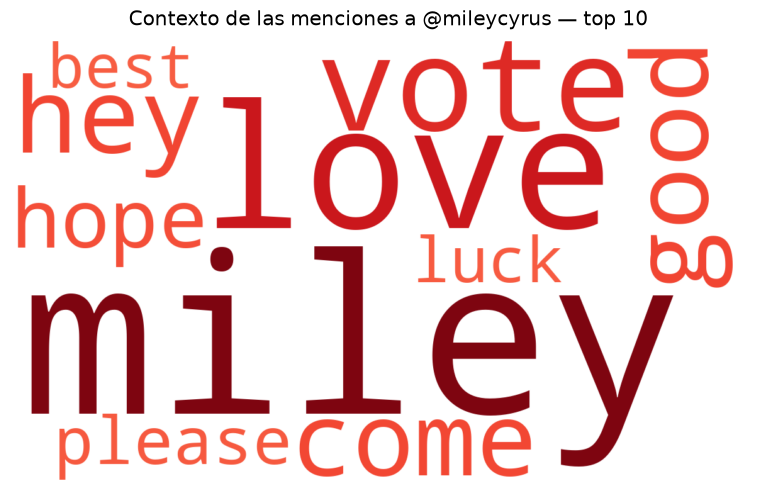

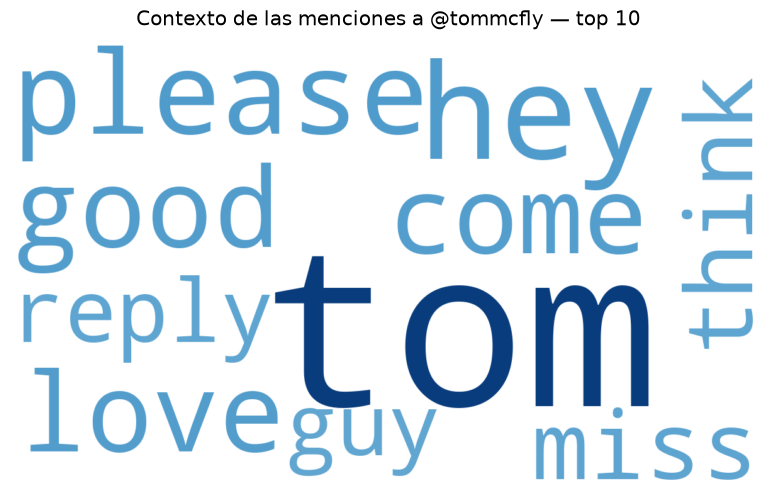

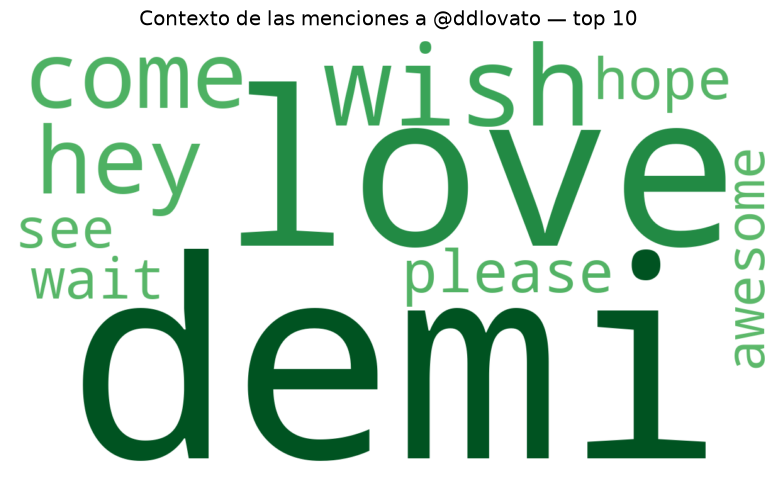

Figuras y tablas guardadas en: C:\Users\jorge.perez\OneDrive - Agencias Way\Escritorio\notas\maestria\7mo trimestre\Text Mining & Image Recognition\Proyecto_final\salidas\problema1


In [16]:
# Wordcloud individual por usuario (archivo aparte por si se necesita suelto)
for j, u in enumerate(TOP_USUARIOS):
    nube = WordCloud(width=1200, height=700, background_color="white",
                     color_func=color_por_frecuencia(PALETAS[j], tops[u]),
                     max_words=TOP_N, random_state=42,
                     relative_scaling=0.55).generate_from_frequencies(tops[u])
    plt.figure(figsize=(9, 5.2))
    plt.imshow(nube, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Contexto de las menciones a @{u} — top {TOP_N}", fontsize=13, pad=10)
    plt.savefig(DIR_SALIDAS / f"wordcloud_{u}.png", bbox_inches="tight", dpi=130)
    plt.show()

# Tabla final de frecuencias
tabla_top = pd.concat([
    pd.DataFrame(contextos_lema[u].most_common(TOP_N), columns=["palabra", "frecuencia"])
      .assign(usuario=f"@{u}", posicion=range(1, TOP_N + 1))
    for u in TOP_USUARIOS
])
tabla_top.to_csv(DIR_SALIDAS / "top10_contexto.csv", index=False, encoding="utf-8")
print("Figuras y tablas guardadas en:", DIR_SALIDAS)

In [17]:
# Evidencia cualitativa: tweets reales detras de las palabras dominantes
VOCATIVOS = {"miley", "tom", "demi", "dem", "demilovato"}   # nombre de pila del propio famoso

for u in TOP_USUARIOS:
    clave = next(w for w, _ in contextos_lema[u].most_common(6) if w not in VOCATIVOS)
    print(f"\n@{u}  —  ejemplos con «{clave}» en el contexto de la mencion")
    print("-" * 86)
    mostrados = 0
    for doc in corpora[u]:
        if clave in normalizar(contexto(doc.content, u)):
            print("  *", textwrap.shorten(html.unescape(doc.content).replace("\n", " "), 100))
            mostrados += 1
            if mostrados == 3:
                break


@mileycyrus  —  ejemplos con «love» en el contexto de la mencion
--------------------------------------------------------------------------------------
  * @mileycyrus i love you, answer me! i'm your number one faaan!
  * @mileycyrus i miley love your music, i think you are amazing and i love your song "the climb" [...]
  * @mileycyrus I love having my feet on the dashboard! But I guess it is in the line of sight of [...]

@tommcfly  —  ejemplos con «hey» en el contexto de la mencion
--------------------------------------------------------------------------------------
  * @tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line i was [...]
  * @tommcfly hey, no chance of adding brighton or eastbourne to the UCAP tour? gutted im missing [...]
  * @tommcfly Hey, Tommy!! How was the concert here in Amsterdam? I wish I could be there! but I [...]

@ddlovato  —  ejemplos con «love» en el contexto de la mencion
--------------------------------------------------

## 1.7 Respuesta: ¿Razón por la que citan a cada usuario?

### Quiénes son

| # | Usuario | Tweets que lo citan | Quién es |
|---|---|---|---|
| 1 | `@mileycyrus` | 4,562 | Miley Cyrus — *Hannah Montana*, Disney Channel |
| 2 | `@tommcfly` | 3,898 | Tom Fletcher — vocalista y guitarrista de **McFly** |
| 3 | `@ddlovato` | 3,460 | Demi Lovato — cantante y actriz, Disney Channel |

Los tres son **celebridades del pop adolescente de 2009**, y no es casualidad: el dataset se
recolectó entre **abril y junio de 2009** (lo confirma el rango de timestamps), justo cuando
el *fandom* adolescente colonizó Twitter. El resto del top 20 lo ocupan casi solo músicos y
actores del mismo circuito (Jonas Brothers, David Archuleta, Taylor Swift, Selena Gomez):
la «popularidad» que mide este dataset es **fama mediática**, no influencia intelectual ni
autoridad temática. Ninguno de los tres supera el **0.3 %** de los tweets, pero eso basta para
destacar sobre 343,632 handles distintos.

### Por qué los citan

El contexto de la mención muestra **tres motivos** que se repiten en los tres corpus, con
pesos distintos:

**1. Vocativo: le hablan *a* la persona, no *sobre* la persona.**
La palabra más frecuente en los tres casos es el **nombre de pila** del propio famoso
(`miley` 599, `tom` 572, `demi` 424), seguida de `hey` y `please`. Esto es un hallazgo, no
ruido: revela que estos tweets **no son conversación entre terceros sino mensajes dirigidos**.
El usuario no es un *tema*, es un *destinatario*. Twitter en 2009 era la primera vez que un
fan podía escribirle directamente a una estrella, y el corpus captura exactamente ese
comportamiento. (Por eso el nombre de pila se dejó en la nube: confirma además que la ventana
de contexto está leyendo la zona correcta del tweet.)

**2. Afecto y admiración.** `love` aparece en el top 3 de los tres usuarios (361 / 139 / 257),
acompañado de `good`, `hope`, `best`, `miss`, `awesome`. Es expresión de fandom pura:
*«i love you, answer me! i'm your number one faaan!»*.

**3. Petición concreta.** `please`, `come`, `reply`, `vote`, `wait`, `see` — el fan pide algo:
que responda, que vaya de gira a su país, que gane un premio.

### El matiz que distingue a cada uno

- **@mileycyrus — campaña de votos.** Es el único donde **`vote` entra al top 3** (277
  apariciones en contexto, 362 tweets la contienen), junto a `luck` y `best`. Corresponde a
  las votaciones de premios de 2009: los fans se organizaban por Twitter para votar en bloque
  (*«I VOTE EVERY DAY FOR YOU!!!»*, *«they closed the voting... Hope you win it!»*). La citan
  para **movilizar apoyo y desearle suerte** en presentaciones y premiaciones.

- **@tommcfly — expectativa de respuesta.** Destacan `reply` (98), `guy` (95), `think` (100) y
  `please` empatado con `hey` en lo más alto. Es el más **conversacional** de los tres: un
  músico que efectivamente contestaba a sus seguidores, así que lo citan **esperando
  respuesta**, con frustración explícita cuando no llega (*«WHY DONT YOU REPLY TO ME?»*,
  *«I never get a reply»*). También aparecen peticiones de gira: *«no chance of adding
  brighton to the UCAP tour?»*.

- **@ddlovato — giras y conciertos.** Sobresalen `wish` (170), `come` (121), `wait` (99) y
  `see` (97). El patrón dominante es **«can't wait to see you» / «come to my country»**: la
  citan pidiendo fechas de concierto y lamentando no poder asistir (*«wish i could go to the
  dallas show»*, *«WHY DO YOU NOT COME TO AUSTRIA?»*).

### Respuesta en una frase

> Los citan porque son **famosos del pop adolescente a los que el fan quiere alcanzar
> directamente**: para declararles afecto (`love`), pedirles una respuesta (`please`,
> `reply`), reclamarles un concierto (`come`, `wait`) o movilizar votos a su favor (`vote`).
> No se los menciona como fuente de información, sino como **destinatario emocional**.

### Nota sobre stemming vs. lemmatización

La tabla comparativa de §1.5 muestra que ambos producen prácticamente el mismo ranking; la
diferencia es de **legibilidad**: el stemmer devuelve `pleas`, `repli`, `awesom`, formas que no
son palabras y que en una nube se leerían mal. Por eso el wordcloud usa el **lema**. El stem
sí aporta cuando lo que importa es agrupar variantes (`loving`/`loves`/`loved` colapsan a la
misma raíz), y por eso ligeramente eleva algunos conteos (`love` 371 con stem contra 361 con
lema en @mileycyrus).